# Phase 1 — Intégration Complète & Scoring
## Simulateur Iron Dome — PFA ENSTAB
### Semaine 3 : Scénarios complets + évaluation des performances

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import sys
sys.path.append('../src')
from simulation.rocket import Rocket, RocketRK4, ThreatGenerator
from simulation.interceptor import Interceptor, EngagementManager

## 1. Système de Scoring
Évalue la performance globale du système d'interception selon 4 critères :
- **Taux d'interception** (40%) : pourcentage de menaces neutralisées
- **Efficacité** (20%) : ratio missiles utilisés / interceptions réussies
- **Altitude d'interception** (20%) : plus haut = plus sûr pour la zone protégée
- **Temps de réaction** (20%) : rapidité de l'interception

In [2]:
class ScoringSystem:
    """
    Système de scoring pour évaluer les performances
    du système de défense anti-aérienne.
    """
    
    def evaluer_scenario(self, resultats):
        """
        Calcule un score détaillé pour un scénario donné.
        resultats = sortie de EngagementManager.gerer_salve()
        """
        details = resultats['details']
        
        altitudes = []
        temps = []
        distances_min = []
        
        for r in details:
            ev = r['evaluation']
            if ev['interception'] is not None and ev['interception']['intercepte']:
                altitudes.append(ev['interception']['missile_y'][-1])
                temps.append(ev['interception']['temps_interception'])
                distances_min.append(ev['interception']['distance_min'])
        
        # Métriques individuelles
        score = {
            'taux_interception': resultats['taux_interception'],
            'total_menaces': resultats['total_menaces'],
            'menaces_dangereuses': resultats['menaces_dangereuses'],
            'interceptions': resultats['interceptions'],
            'ignorees': resultats['ignorees'],
            'missiles_utilises': resultats['missiles_utilises'],
            'efficacite': resultats['interceptions'] / max(resultats['missiles_utilises'], 1),
            'altitude_moyenne': np.mean(altitudes) if altitudes else 0,
            'altitude_min': np.min(altitudes) if altitudes else 0,
            'temps_moyen': np.mean(temps) if temps else 0,
            'distance_min_moyenne': np.mean(distances_min) if distances_min else 0,
        }
        
        # Score global sur 100
        s = 0
        s += min(score['taux_interception'], 100) * 0.4
        s += score['efficacite'] * 100 * 0.2
        s += min(score['altitude_moyenne'] / 1000, 1) * 100 * 0.2
        s += max(0, (1 - score['temps_moyen'] / 30)) * 100 * 0.2
        score['score_global'] = round(s, 1)
        
        return score
    
    def afficher_score(self, score, nom_scenario=""):
        """Affiche un rapport de score formaté."""
        print(f"\n{'='*50}")
        print(f"  RAPPORT DE SCORE — {nom_scenario}")
        print(f"{'='*50}")
        print(f"  Menaces totales        : {score['total_menaces']}")
        print(f"  Menaces dangereuses    : {score['menaces_dangereuses']}")
        print(f"  Ignorees (hors zone)   : {score['ignorees']}")
        print(f"  Missiles utilises      : {score['missiles_utilises']}")
        print(f"  Interceptions reussies : {score['interceptions']}")
        print(f"{'─'*50}")
        print(f"  Taux d'interception    : {score['taux_interception']:.1f}%")
        print(f"  Efficacite             : {score['efficacite']*100:.1f}%")
        print(f"  Altitude moy. intercep.: {score['altitude_moyenne']:.0f} m")
        print(f"  Altitude min. intercep.: {score['altitude_min']:.0f} m")
        print(f"  Temps moyen intercep.  : {score['temps_moyen']:.2f} s")
        print(f"  Distance min. moyenne  : {score['distance_min_moyenne']:.1f} m")
        print(f"{'─'*50}")
        print(f"  SCORE GLOBAL           : {score['score_global']} / 100")
        print(f"{'='*50}")

## 2. Scénario S1 — Menace unique, trajectoire simple
Objectif : valider le modèle de base avec une seule roquette.



  RAPPORT DE SCORE — S1 — Menace unique
  Menaces totales        : 1
  Menaces dangereuses    : 1
  Ignorees (hors zone)   : 0
  Missiles utilises      : 1
  Interceptions reussies : 1
──────────────────────────────────────────────────
  Taux d'interception    : 100.0%
  Efficacite             : 100.0%
  Altitude moy. intercep.: 1453 m
  Altitude min. intercep.: 1453 m
  Temps moyen intercep.  : 3.70 s
  Distance min. moyenne  : 23.1 m
──────────────────────────────────────────────────
  SCORE GLOBAL           : 97.5 / 100


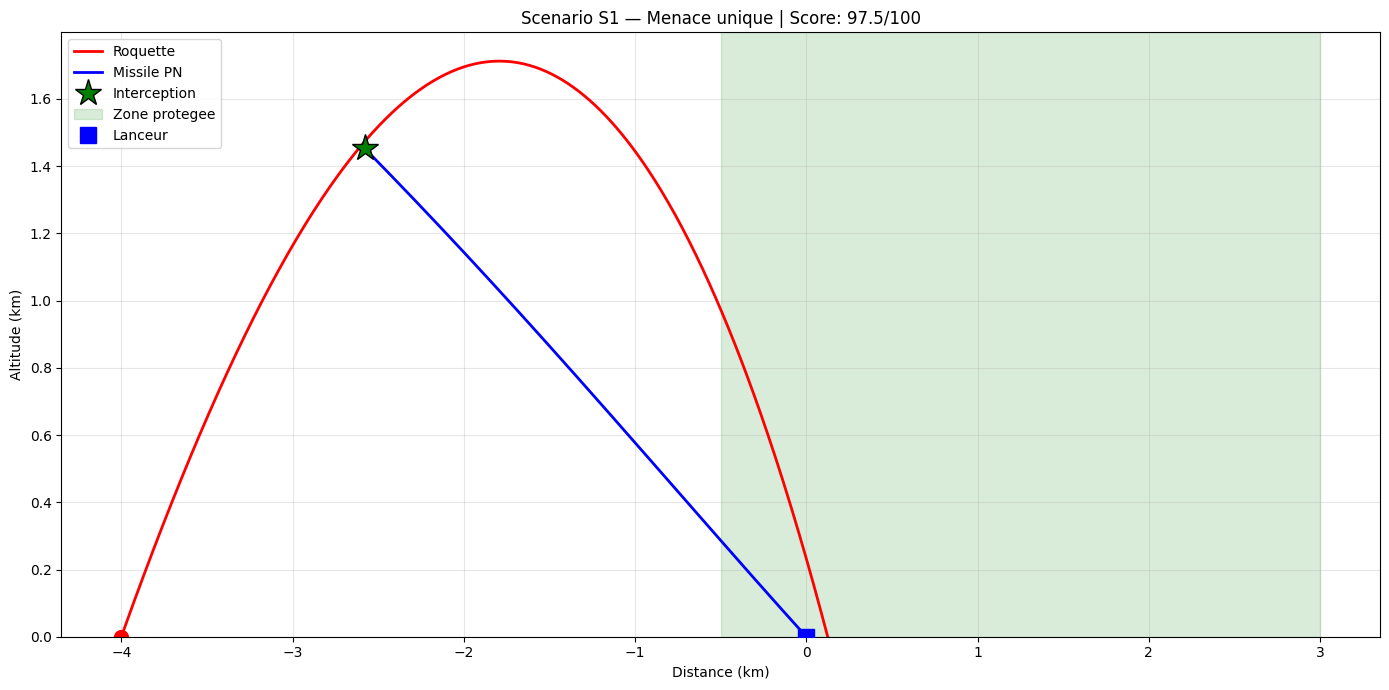

In [3]:
# Scénario S1 : une seule roquette visant la zone protégée
roquette_s1 = RocketRK4(v0=250, angle_deg=55, masse=100, Cd=0.3, A=0.05,
                         x0=-4000, y0=0)

manager = EngagementManager(
    zone_x_min=-500, zone_x_max=3000,
    interceptor_pos=(0, 0), missile_vitesse=800, kill_radius=30
)

resultats_s1 = manager.gerer_salve([roquette_s1])

scoring = ScoringSystem()
score_s1 = scoring.evaluer_scenario(resultats_s1)
scoring.afficher_score(score_s1, "S1 — Menace unique")

# Visualisation
fig, ax = plt.subplots(figsize=(14, 7))

r = resultats_s1['details'][0]
t_c, x_c, y_c = r['trajectoire']
ev = r['evaluation']

ax.plot(x_c/1000, y_c/1000, 'r-', linewidth=2, label='Roquette')
ax.plot(x_c[0]/1000, y_c[0]/1000, 'ro', markersize=10)

if ev['interception'] is not None and ev['interception']['intercepte']:
    mx = ev['interception']['missile_x']
    my = ev['interception']['missile_y']
    ax.plot(mx/1000, my/1000, 'b-', linewidth=2, label='Missile PN')
    ax.plot(mx[-1]/1000, my[-1]/1000, 'g*', markersize=20,
            markeredgecolor='black', zorder=5, label='Interception')

ax.axvspan(-0.5, 3, alpha=0.15, color='green', label='Zone protegee')
ax.plot(0, 0, 'bs', markersize=12, label='Lanceur', zorder=5)
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Altitude (km)')
ax.set_title(f'Scenario S1 — Menace unique | Score: {score_s1["score_global"]}/100')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 3. Scénario S2 — Salves multiples simultanées
Objectif : tester la priorisation et la gestion de menaces multiples.


  RAPPORT DE SCORE — S2 — Salve de 15 roquettes
  Menaces totales        : 15
  Menaces dangereuses    : 3
  Ignorees (hors zone)   : 12
  Missiles utilises      : 3
  Interceptions reussies : 3
──────────────────────────────────────────────────
  Taux d'interception    : 100.0%
  Efficacite             : 100.0%
  Altitude moy. intercep.: 2194 m
  Altitude min. intercep.: 638 m
  Temps moyen intercep.  : 4.49 s
  Distance min. moyenne  : 25.2 m
──────────────────────────────────────────────────
  SCORE GLOBAL           : 97.0 / 100


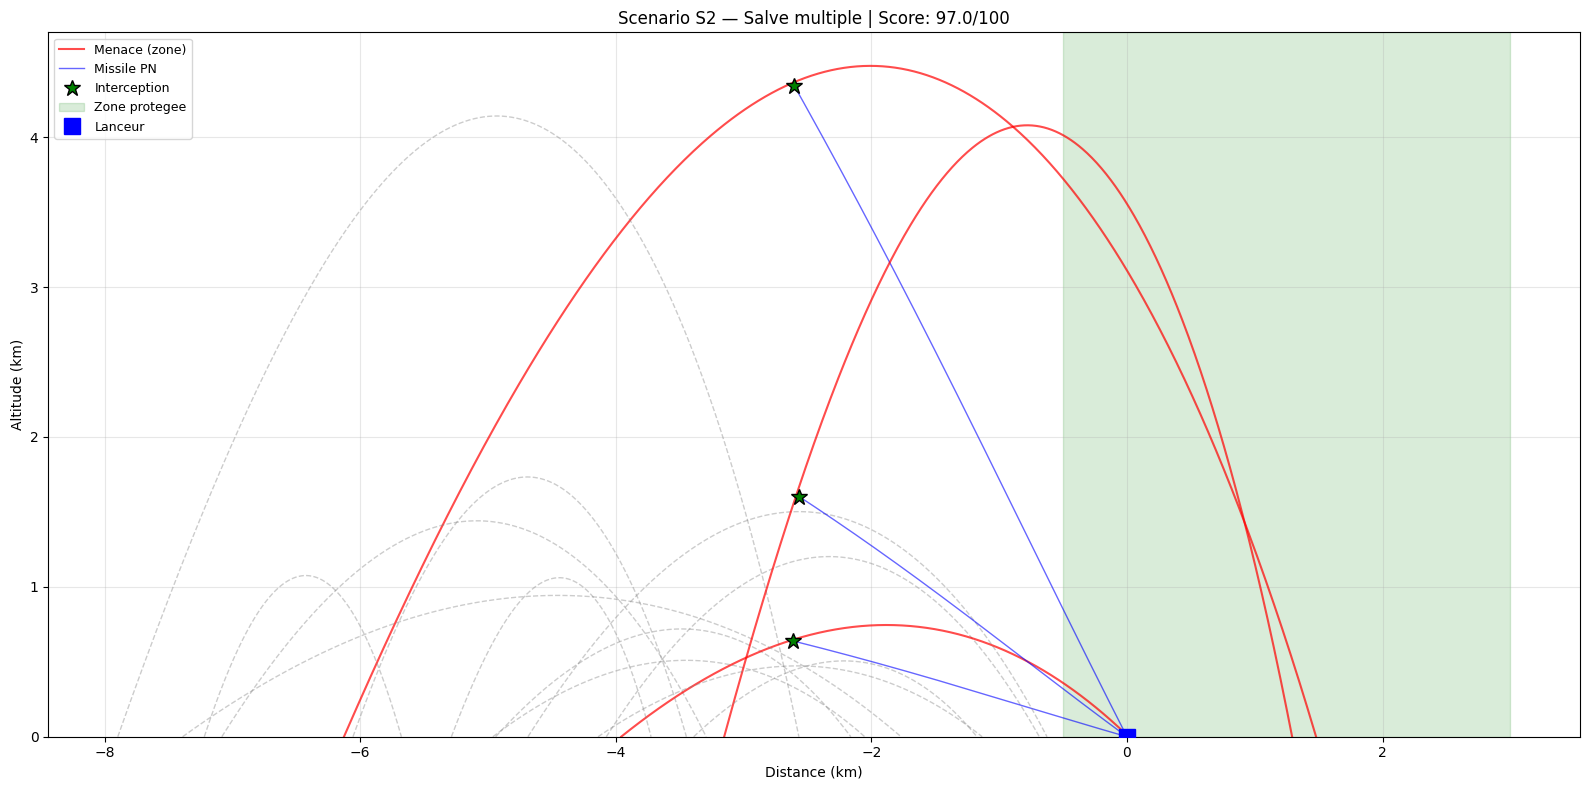

In [4]:
gen = ThreatGenerator(seed=42)
salve_s2 = gen.generer_salve(n=15)

resultats_s2 = manager.gerer_salve(salve_s2)
score_s2 = scoring.evaluer_scenario(resultats_s2)
scoring.afficher_score(score_s2, "S2 — Salve de 15 roquettes")

# Visualisation
fig, ax = plt.subplots(figsize=(16, 8))

for i, r in enumerate(resultats_s2['details']):
    t_c, x_c, y_c = r['trajectoire']
    ev = r['evaluation']
    
    if ev['dans_zone']:
        ax.plot(x_c/1000, y_c/1000, 'r-', linewidth=1.5, alpha=0.7,
                label='Menace (zone)' if i == 0 else '')
        if ev['interception'] is not None and ev['interception']['intercepte']:
            mx = ev['interception']['missile_x']
            my = ev['interception']['missile_y']
            ax.plot(mx/1000, my/1000, 'b-', linewidth=1, alpha=0.6,
                    label='Missile PN' if i == 0 else '')
            ax.plot(mx[-1]/1000, my[-1]/1000, 'g*', markersize=12,
                    markeredgecolor='black', zorder=5,
                    label='Interception' if i == 0 else '')
    else:
        ax.plot(x_c/1000, y_c/1000, color='gray', linewidth=1,
                linestyle='--', alpha=0.4,
                label='Ignoree' if i == 0 else '')

ax.axvspan(-0.5, 3, alpha=0.15, color='green', label='Zone protegee')
ax.plot(0, 0, 'bs', markersize=12, label='Lanceur', zorder=5)
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Altitude (km)')
ax.set_title(f'Scenario S2 — Salve multiple | Score: {score_s2["score_global"]}/100')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 4. Scénario S3 — Trajectoires bruitées (simulation radar)
Objectif : évaluer la robustesse quand les positions radar sont imprécises.

In [5]:
def ajouter_bruit_radar(x, y, sigma=50):
    """
    Simule le bruit de mesure d'un radar.
    sigma = ecart-type du bruit en mètres.
    """
    bruit_x = np.random.normal(0, sigma, len(x))
    bruit_y = np.random.normal(0, sigma, len(y))
    x_bruite = x + bruit_x
    y_bruite = np.maximum(y + bruit_y, 0)  # pas sous le sol
    return x_bruite, y_bruite

# Tester avec différents niveaux de bruit
niveaux_bruit = [0, 25, 50, 100, 200]
scores_bruit = []

gen = ThreatGenerator(seed=42)

for sigma in niveaux_bruit:
    np.random.seed(99)  # même bruit pour comparer
    salve = gen.generer_salve(n=10)
    
    # Recréer le generator avec même seed pour avoir mêmes roquettes
    gen2 = ThreatGenerator(seed=42)
    salve = gen2.generer_salve(n=10)
    
    resultats_temp = {'details': [], 'total_menaces': len(salve),
                      'menaces_dangereuses': 0, 'ignorees': 0,
                      'interceptions': 0, 'missiles_utilises': 0}
    
    for roquette in salve:
        t_c, x_c, y_c = roquette.trajectoire_rk4(dt=0.1)
        
        # Le manager utilise la vraie trajectoire pour la décision
        x_impact = x_c[-1]
        dans_zone = -500 <= x_impact <= 3000
        
        if dans_zone:
            # Le missile utilise la trajectoire BRUITEE
            np.random.seed(np.random.randint(0, 10000))
            x_b, y_b = ajouter_bruit_radar(x_c, y_c, sigma=sigma)
            
            missile = Interceptor(x0=0, y0=0, vitesse=800, kill_radius=30)
            r = missile.proportional_navigation(x_b, y_b, t_c)
            
            resultats_temp['missiles_utilises'] += 1
            resultats_temp['menaces_dangereuses'] += 1
            if r['intercepte']:
                resultats_temp['interceptions'] += 1
            
            resultats_temp['details'].append({
                'roquette': roquette,
                'trajectoire': (t_c, x_c, y_c),
                'evaluation': {
                    'x_impact': x_impact, 'dans_zone': True,
                    'decision': 'INTERCEPTER', 'interception': r
                }
            })
        else:
            resultats_temp['ignorees'] += 1
            resultats_temp['details'].append({
                'roquette': roquette,
                'trajectoire': (t_c, x_c, y_c),
                'evaluation': {
                    'x_impact': x_impact, 'dans_zone': False,
                    'decision': 'IGNORER', 'interception': None
                }
            })
    
    resultats_temp['taux_interception'] = (
        resultats_temp['interceptions'] / 
        max(resultats_temp['missiles_utilises'], 1) * 100
    )
    
    score = scoring.evaluer_scenario(resultats_temp)
    scores_bruit.append(score)
    print(f"Bruit sigma={sigma:>3}m : taux={score['taux_interception']:>5.1f}% | "
          f"score={score['score_global']}/100")

Bruit sigma=  0m : taux=100.0% | score=96.4/100
Bruit sigma= 25m : taux=100.0% | score=96.4/100
Bruit sigma= 50m : taux=100.0% | score=96.4/100
Bruit sigma=100m : taux= 50.0% | score=53.7/100
Bruit sigma=200m : taux= 50.0% | score=52.7/100


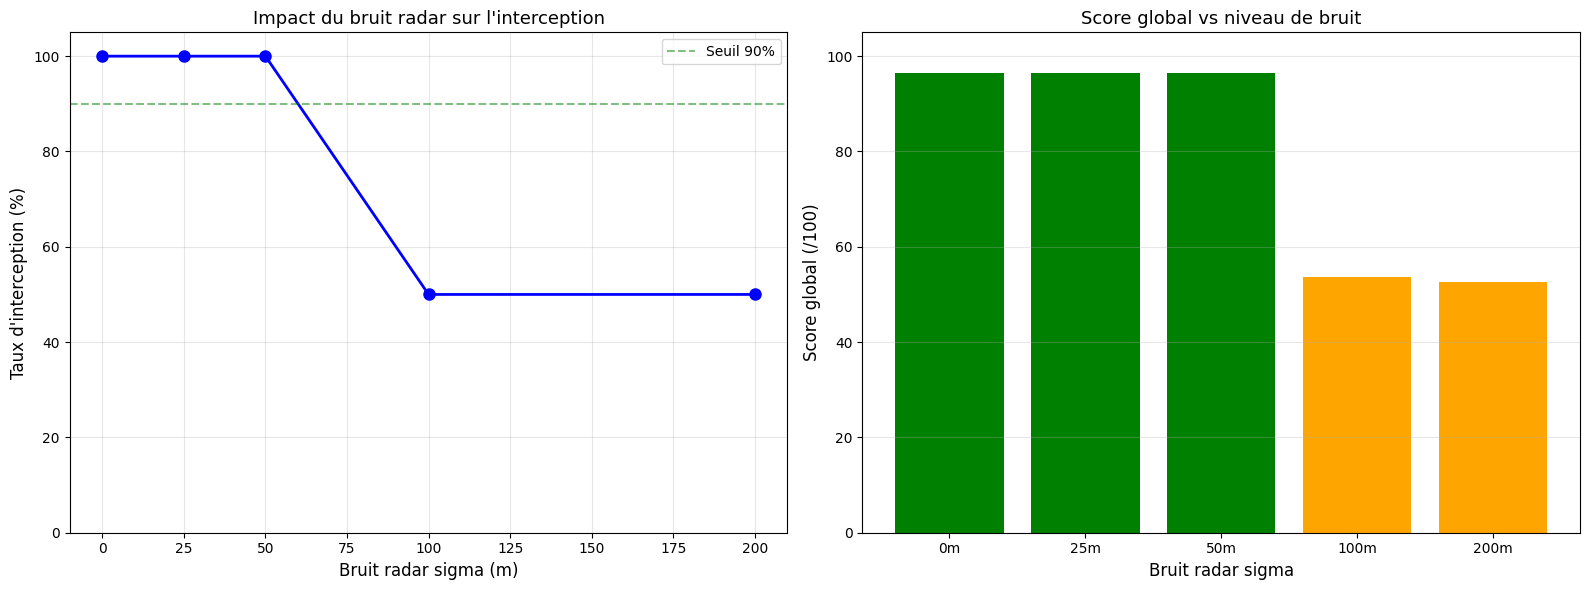

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphe 1 : Taux d'interception vs bruit
taux = [s['taux_interception'] for s in scores_bruit]
axes[0].plot(niveaux_bruit, taux, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Bruit radar sigma (m)', fontsize=12)
axes[0].set_ylabel("Taux d'interception (%)", fontsize=12)
axes[0].set_title("Impact du bruit radar sur l'interception", fontsize=13)
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.5, label='Seuil 90%')
axes[0].legend()

# Graphe 2 : Score global vs bruit
scores_g = [s['score_global'] for s in scores_bruit]
axes[1].bar(range(len(niveaux_bruit)), scores_g, 
            color=['green' if s > 70 else 'orange' if s > 50 else 'red' for s in scores_g])
axes[1].set_xticks(range(len(niveaux_bruit)))
axes[1].set_xticklabels([f'{s}m' for s in niveaux_bruit])
axes[1].set_xlabel('Bruit radar sigma', fontsize=12)
axes[1].set_ylabel('Score global (/100)', fontsize=12)
axes[1].set_title('Score global vs niveau de bruit', fontsize=13)
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Tableau comparatif final — Les 3 scénarios

In [7]:
print(f"{'':>25} | {'S1 Unique':^15} | {'S2 Salve':^15} | {'S3 Bruit=50m':^15}")
print("-" * 75)

s1 = score_s1
s2 = score_s2
s3 = scores_bruit[2]  # sigma=50

lignes = [
    ("Total menaces", 'total_menaces', 'd'),
    ("Menaces dangereuses", 'menaces_dangereuses', 'd'),
    ("Ignorees", 'ignorees', 'd'),
    ("Interceptions", 'interceptions', 'd'),
    ("Taux interception (%)", 'taux_interception', '.1f'),
    ("Efficacite (%)", 'efficacite', '.1%'),
    ("Altitude moy. (m)", 'altitude_moyenne', '.0f'),
    ("Temps moyen (s)", 'temps_moyen', '.2f'),
    ("SCORE GLOBAL (/100)", 'score_global', '.1f'),
]

for nom, cle, fmt in lignes:
    v1 = s1[cle]
    v2 = s2[cle]
    v3 = s3[cle]
    
    if fmt == 'd':
        print(f"{nom:>25} | {v1:^15d} | {v2:^15d} | {v3:^15d}")
    elif fmt == '.1%':
        print(f"{nom:>25} | {v1*100:^15.1f} | {v2*100:^15.1f} | {v3*100:^15.1f}")
    else:
        print(f"{nom:>25} | {v1:^15{fmt}} | {v2:^15{fmt}} | {v3:^15{fmt}}")

                          |    S1 Unique    |    S2 Salve     |  S3 Bruit=50m  
---------------------------------------------------------------------------
            Total menaces |        1        |       15        |       10       
      Menaces dangereuses |        1        |        3        |        2       
                 Ignorees |        0        |       12        |        8       
            Interceptions |        1        |        3        |        2       
    Taux interception (%) |      100.0      |      100.0      |      100.0     
           Efficacite (%) |      100.0      |      100.0      |      100.0     
        Altitude moy. (m) |      1453       |      2194       |      1212      
          Temps moyen (s) |      3.70       |      4.49       |      5.43      
      SCORE GLOBAL (/100) |      97.5       |      97.0       |      96.4      


## 6. Extension 3D — Scénarios complets
Même analyse que la partie 2D, adaptée aux trajectoires 3D avec azimut.

In [8]:
import plotly.graph_objects as go
from simulation.rocket3d import Rocket3D, ThreatGenerator3D
from simulation.interceptor3d import Interceptor3D

# === Manager 3D avec délai de lancement ===
class EngagementManager3D:
    def __init__(self, zone_x_min, zone_x_max, zone_z_min, zone_z_max,
                 interceptor_pos=(0, 0, 0), missile_vitesse=800, kill_radius=30):
        self.zone_x_min = zone_x_min
        self.zone_x_max = zone_x_max
        self.zone_z_min = zone_z_min
        self.zone_z_max = zone_z_max
        self.interceptor_pos = interceptor_pos
        self.missile_vitesse = missile_vitesse
        self.kill_radius = kill_radius
    
    def impact_dans_zone(self, x_impact, z_impact):
        return (self.zone_x_min <= x_impact <= self.zone_x_max and
                self.zone_z_min <= z_impact <= self.zone_z_max)
    
    def _calculer_delai_lancement(self, xc, yc, zc, tc):
        mx, my, mz = self.interceptor_pos
        for i in range(len(tc)):
            d = np.sqrt((xc[i]-mx)**2 + (yc[i]-my)**2 + (zc[i]-mz)**2)
            t_vol_missile = d / self.missile_vitesse
            dans_zone_x = self.zone_x_min - 2000 <= xc[i] <= self.zone_x_max + 1000
            altitude_ok = yc[i] > 500
            if t_vol_missile <= tc[i] and dans_zone_x and altitude_ok:
                delai = max(0, tc[i] - t_vol_missile - 1.0)
                return delai
        return 0
    
    def gerer_salve(self, salve):
        resultats = []
        missiles_utilises = 0
        interceptions = 0
        ignorees = 0
        for roquette in salve:
            tc, xc, yc, zc = roquette.trajectoire_rk4(dt=0.1)
            dans_zone = self.impact_dans_zone(xc[-1], zc[-1])
            if dans_zone:
                delai = self._calculer_delai_lancement(xc, yc, zc, tc)
                idx_debut = np.searchsorted(tc, delai)
                if idx_debut >= len(tc) - 10:
                    idx_debut = 0
                xc_t = xc[idx_debut:]
                yc_t = yc[idx_debut:]
                zc_t = zc[idx_debut:]
                tc_t = tc[idx_debut:] - tc[idx_debut]
                missile = Interceptor3D(
                    *self.interceptor_pos,
                    vitesse=self.missile_vitesse,
                    kill_radius=self.kill_radius
                )
                r = missile.proportional_navigation_3d(xc_t, yc_t, zc_t, tc_t)
                missiles_utilises += 1
                if r['intercepte']:
                    interceptions += 1
                resultats.append({
                    'roquette': roquette,
                    'trajectoire': (tc, xc, yc, zc),
                    'dans_zone': True,
                    'interception': r
                })
            else:
                ignorees += 1
                resultats.append({
                    'roquette': roquette,
                    'trajectoire': (tc, xc, yc, zc),
                    'dans_zone': False,
                    'interception': None
                })
        return {
            'details': resultats, 'total': len(salve),
            'dangereuses': missiles_utilises, 'ignorees': ignorees,
            'interceptions': interceptions,
            'taux': interceptions / max(missiles_utilises, 1) * 100
        }

# === Scene 3D de base ===
def creer_scene_de_base():
    fig = go.Figure()
    zone_x = [-0.5, 3, 3, -0.5, -0.5]
    zone_z = [-1.5, -1.5, 1.5, 1.5, -1.5]
    fig.add_trace(go.Scatter3d(
        x=zone_x, y=zone_z, z=[0]*5,
        mode='lines', line=dict(color='green', width=6),
        name='Zone protegee'
    ))
    fig.add_trace(go.Mesh3d(
        x=[-0.5, 3, 3, -0.5], y=[-1.5, -1.5, 1.5, 1.5], z=[0]*4,
        i=[0, 0], j=[1, 2], k=[2, 3],
        color='lightgreen', opacity=0.3, showscale=False, hoverinfo='skip'
    ))
    fig.add_trace(go.Scatter3d(
        x=[0], y=[0], z=[0],
        mode='markers',
        marker=dict(size=10, color='blue', symbol='diamond',
                    line=dict(color='black', width=2)),
        name='Lanceur'
    ))
    fig.update_layout(
        scene=dict(
            xaxis_title='Distance X (km)',
            yaxis_title='Lateral Z (km)',
            zaxis_title='Altitude Y (km)',
            aspectmode='manual',
            aspectratio=dict(x=2.5, y=1.2, z=0.8),
            camera=dict(
                eye=dict(x=-1.2, y=-1.8, z=0.8),
                center=dict(x=-0.3, y=0, z=0.1)
            )
        ),
        width=1000, height=700
    )
    return fig

# === Scoring 3D ===
class ScoringSystem3D:
    
    
    def evaluer_scenario(self, resultats):
        altitudes = []
        temps = []
        distances_min = []
        
        for r in resultats['details']:
            if r['interception'] is not None and r['interception']['intercepte']:
                altitudes.append(r['interception']['missile_y'][-1])
                temps.append(r['interception']['temps_interception'])
                distances_min.append(r['interception']['distance_min'])
        
        score = {
            'total_menaces': resultats['total'],
            'menaces_dangereuses': resultats['dangereuses'],
            'ignorees': resultats['ignorees'],
            'interceptions': resultats['interceptions'],
            'missiles_utilises': resultats['dangereuses'],
            'taux_interception': resultats['taux'],
            'efficacite': resultats['interceptions'] / max(resultats['dangereuses'], 1),
            'altitude_moyenne': np.mean(altitudes) if altitudes else 0,
            'altitude_min': np.min(altitudes) if altitudes else 0,
            'temps_moyen': np.mean(temps) if temps else 0,
            'distance_min_moyenne': np.mean(distances_min) if distances_min else 0,
        }
        
        # Score global sur 100
        s = 0
        s += min(score['taux_interception'], 100) * 0.4
        s += score['efficacite'] * 100 * 0.2
        s += min(score['altitude_moyenne'] / 1000, 1) * 100 * 0.2
        # Temps : seulement si au moins une interception
        if score['interceptions'] > 0:
            s += max(0, (1 - score['temps_moyen'] / 30)) * 100 * 0.2
        score['score_global'] = round(s, 1)
        
        return score

scoring3d = ScoringSystem3D()

# === Manager et Scoring ===
manager3d = EngagementManager3D(
    zone_x_min=-500, zone_x_max=3000,
    zone_z_min=-1500, zone_z_max=1500,
    interceptor_pos=(0, 0, 0)
)
scoring3d = ScoringSystem3D()
print("Setup 3D OK")

Setup 3D OK


### Scenario S1 3D — Menace unique

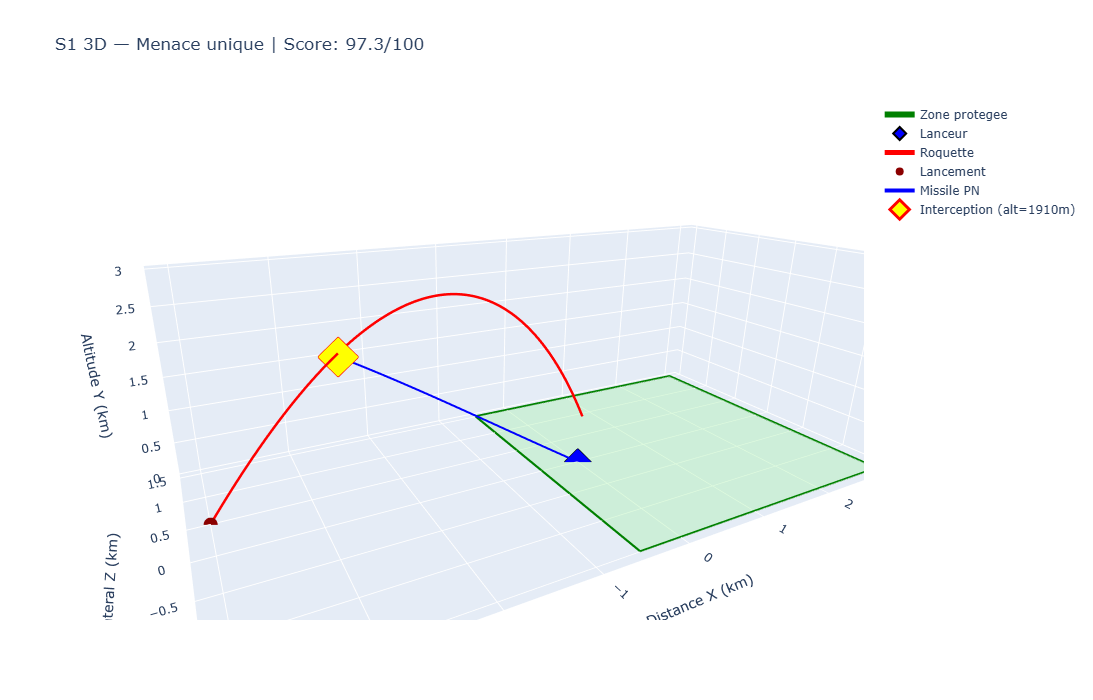

In [9]:
# === S1 : Menace unique 3D ===
roquette_s1 = Rocket3D(v0=300, theta_deg=60, phi_deg=5, masse=100,
                        Cd=0.3, A=0.05, x0=-4000, y0=0, z0=500)

res_s1_3d = manager3d.gerer_salve([roquette_s1])
score_s1_3d = scoring3d.evaluer_scenario(res_s1_3d)

# Visualisation
fig = creer_scene_de_base()
r = res_s1_3d['details'][0]
tc, xc, yc, zc = r['trajectoire']

fig.add_trace(go.Scatter3d(
    x=xc/1000, y=zc/1000, z=yc/1000,
    mode='lines', line=dict(color='red', width=5), name='Roquette'
))
fig.add_trace(go.Scatter3d(
    x=[xc[0]/1000], y=[zc[0]/1000], z=[yc[0]/1000],
    mode='markers', marker=dict(size=8, color='darkred'), name='Lancement'
))

if r['interception'] is not None:
    mx = r['interception']['missile_x']
    my = r['interception']['missile_y']
    mz = r['interception']['missile_z']
    fig.add_trace(go.Scatter3d(
        x=mx/1000, y=mz/1000, z=my/1000,
        mode='lines', line=dict(color='blue', width=4), name='Missile PN'
    ))
    if r['interception']['intercepte']:
        fig.add_trace(go.Scatter3d(
            x=[mx[-1]/1000], y=[mz[-1]/1000], z=[my[-1]/1000],
            mode='markers',
            marker=dict(size=15, color='yellow', symbol='diamond',
                        line=dict(color='red', width=3)),
            name=f'Interception (alt={my[-1]:.0f}m)'
        ))

fig.update_layout(
    title=f'S1 3D — Menace unique | Score: {score_s1_3d["score_global"]}/100',
    scene=dict(zaxis=dict(range=[0, max(yc/1000)*1.2]))
)
fig.show()

### Scenario S2 3D — Salve multiple

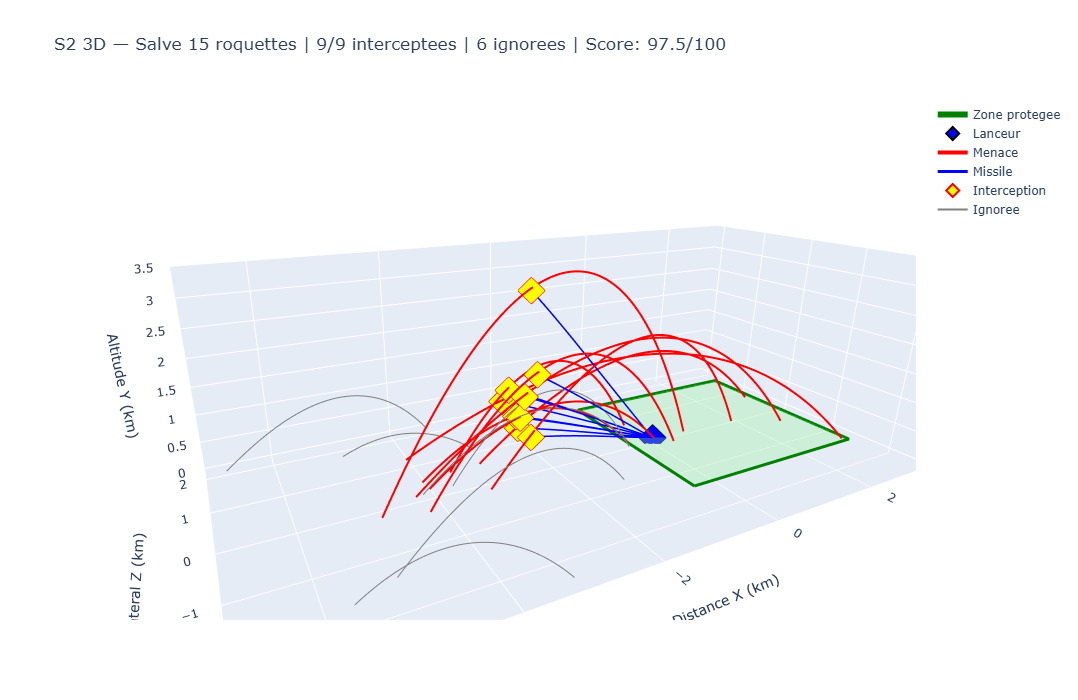

Dangereuses: 9, Ignorees: 6, Interceptions: 9


In [10]:
# === S2 : Salve 3D ===
class ThreatGenerator3D_Realistic:
    def __init__(self, seed=42):
        np.random.seed(seed)
    def generer_menace_zone(self):
        return Rocket3D(
            v0=np.random.uniform(200, 350),
            theta_deg=np.random.uniform(40, 60),
            phi_deg=np.random.uniform(-5, 5),
            masse=np.random.uniform(80, 150),
            Cd=np.random.uniform(0.2, 0.4), A=0.05,
            x0=np.random.uniform(-4500, -3000), y0=0,
            z0=np.random.uniform(-500, 500))
    def generer_menace_random(self):
        return Rocket3D(
            v0=np.random.uniform(150, 400),
            theta_deg=np.random.uniform(30, 75),
            phi_deg=np.random.uniform(-20, 20),
            masse=np.random.uniform(50, 200),
            Cd=np.random.uniform(0.2, 0.5), A=0.05,
            x0=np.random.uniform(-7000, -3000), y0=0,
            z0=np.random.uniform(-2000, 2000))
    def generer_salve(self, n=15):
        salve = []
        n_zone = int(n * 0.6)
        for _ in range(n_zone):
            salve.append(self.generer_menace_zone())
        for _ in range(n - n_zone):
            salve.append(self.generer_menace_random())
        np.random.shuffle(salve)
        return salve

gen3d_real = ThreatGenerator3D_Realistic(seed=42)
salve_s2_3d = gen3d_real.generer_salve(n=15)
res_s2_3d = manager3d.gerer_salve(salve_s2_3d)
score_s2_3d = scoring3d.evaluer_scenario(res_s2_3d)

# Visualisation
fig = creer_scene_de_base()
first_m, first_mi, first_int, first_ign = True, True, True, True

for r in res_s2_3d['details']:
    tc, xc, yc, zc = r['trajectoire']
    if r['dans_zone']:
        fig.add_trace(go.Scatter3d(
            x=xc/1000, y=zc/1000, z=yc/1000,
            mode='lines', line=dict(color='red', width=4),
            name='Menace' if first_m else None, showlegend=first_m))
        first_m = False
        if r['interception'] is not None:
            mx, my, mz = r['interception']['missile_x'], r['interception']['missile_y'], r['interception']['missile_z']
            fig.add_trace(go.Scatter3d(
                x=mx/1000, y=mz/1000, z=my/1000,
                mode='lines', line=dict(color='blue', width=3),
                name='Missile' if first_mi else None, showlegend=first_mi))
            first_mi = False
            if r['interception']['intercepte']:
                fig.add_trace(go.Scatter3d(
                    x=[mx[-1]/1000], y=[mz[-1]/1000], z=[my[-1]/1000],
                    mode='markers', marker=dict(size=10, color='yellow', symbol='diamond', line=dict(color='red', width=2)),
                    name='Interception' if first_int else None, showlegend=first_int))
                first_int = False
    else:
        fig.add_trace(go.Scatter3d(
            x=xc/1000, y=zc/1000, z=yc/1000,
            mode='lines', line=dict(color='gray', width=2),
            name='Ignoree' if first_ign else None, showlegend=first_ign))
        first_ign = False

fig.update_layout(title=f'S2 3D — Salve 15 roquettes | {res_s2_3d["interceptions"]}/{res_s2_3d["dangereuses"]} interceptees | {res_s2_3d["ignorees"]} ignorees | Score: {score_s2_3d["score_global"]}/100')
fig.show()

print(f"Dangereuses: {res_s2_3d['dangereuses']}, Ignorees: {res_s2_3d['ignorees']}, Interceptions: {res_s2_3d['interceptions']}")

### Scenario S3 3D — Bruit radar (SANS filtrage)
Le missile recoit les mesures bruitees directement. Les resultats degrades justifient l'utilisation du filtre de Kalman.

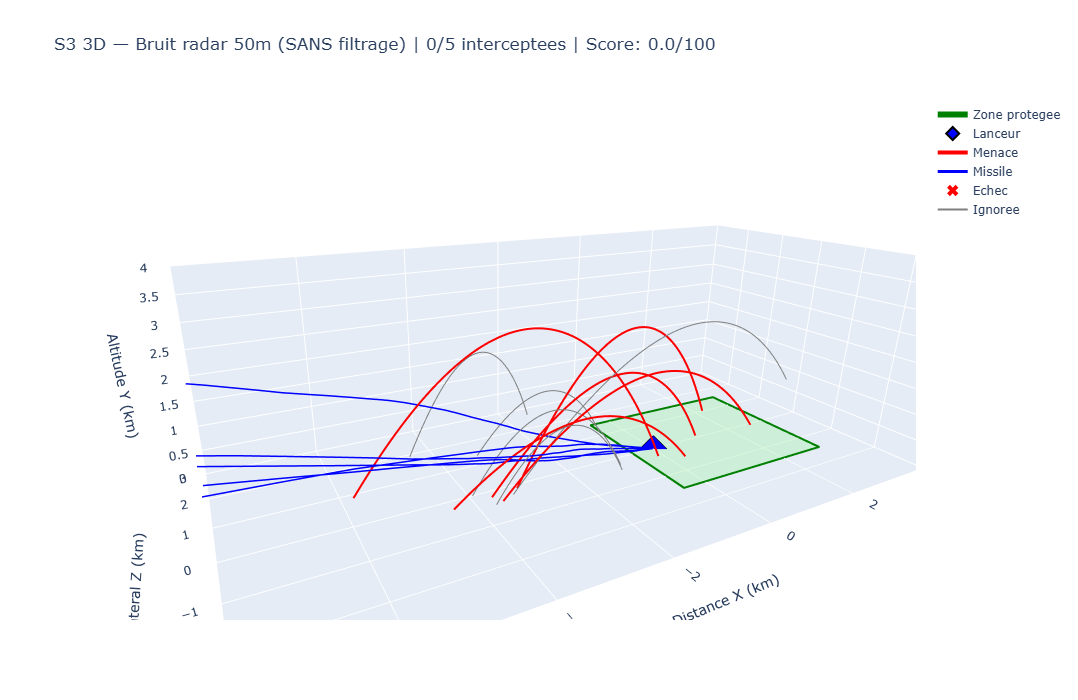

Taux interception SANS filtrage : 0%
Le bruit radar degrade fortement les performances en 3D


In [11]:
# === S3 : Salve 3D avec bruit radar (SANS filtrage) ===
np.random.seed(99)
gen3d_s3 = ThreatGenerator3D_Realistic(seed=99)  # même générateur que S2
salve_s3_3d = gen3d_s3.generer_salve(n=10)

res_s3_temp = {'details': [], 'total': len(salve_s3_3d),
               'dangereuses': 0, 'ignorees': 0, 'interceptions': 0}
sigma_bruit = 50

for roquette in salve_s3_3d:
    tc, xc, yc, zc = roquette.trajectoire_rk4(dt=0.1)
    dans_zone = manager3d.impact_dans_zone(xc[-1], zc[-1])
    if dans_zone:
        np.random.seed(np.random.randint(0, 10000))
        x_b = xc + np.random.normal(0, sigma_bruit, len(xc))
        y_b = np.maximum(yc + np.random.normal(0, sigma_bruit, len(yc)), 0)
        z_b = zc + np.random.normal(0, sigma_bruit, len(zc))
        missile = Interceptor3D(x0=0, y0=0, z0=0, vitesse=800, kill_radius=30)
        r = missile.proportional_navigation_3d(x_b, y_b, z_b, tc)
        res_s3_temp['dangereuses'] += 1
        if r['intercepte']:
            res_s3_temp['interceptions'] += 1
        res_s3_temp['details'].append({
            'roquette': roquette, 'trajectoire': (tc, xc, yc, zc),
            'dans_zone': True, 'interception': r})
    else:
        res_s3_temp['ignorees'] += 1
        res_s3_temp['details'].append({
            'roquette': roquette, 'trajectoire': (tc, xc, yc, zc),
            'dans_zone': False, 'interception': None})

res_s3_temp['taux'] = res_s3_temp['interceptions'] / max(res_s3_temp['dangereuses'], 1) * 100
score_s3_3d = scoring3d.evaluer_scenario(res_s3_temp)

# Visualisation avec limites d'axes
fig = creer_scene_de_base()
first_m, first_mi, first_ok, first_fail, first_ign = True, True, True, True, True

for r in res_s3_temp['details']:
    tc, xc, yc, zc = r['trajectoire']
    if r['dans_zone']:
        fig.add_trace(go.Scatter3d(
            x=xc/1000, y=zc/1000, z=yc/1000,
            mode='lines', line=dict(color='red', width=4),
            name='Menace' if first_m else None, showlegend=first_m))
        first_m = False
        if r['interception'] is not None:
            mx, my, mz = r['interception']['missile_x'], r['interception']['missile_y'], r['interception']['missile_z']
            # Limiter la trajectoire du missile à 10km max
            dist = np.sqrt(mx**2 + my**2 + mz**2)
            mask = dist < 10000
            mx, my, mz = mx[mask], my[mask], mz[mask]
            if len(mx) > 0:
                fig.add_trace(go.Scatter3d(
                    x=mx/1000, y=mz/1000, z=my/1000,
                    mode='lines', line=dict(color='blue', width=3),
                    name='Missile' if first_mi else None, showlegend=first_mi))
                first_mi = False
                if r['interception']['intercepte']:
                    fig.add_trace(go.Scatter3d(
                        x=[mx[-1]/1000], y=[mz[-1]/1000], z=[my[-1]/1000],
                        mode='markers', marker=dict(size=10, color='yellow', symbol='diamond', line=dict(color='red', width=2)),
                        name='Interception' if first_ok else None, showlegend=first_ok))
                    first_ok = False
                else:
                    fig.add_trace(go.Scatter3d(
                        x=[mx[-1]/1000], y=[mz[-1]/1000], z=[my[-1]/1000],
                        mode='markers', marker=dict(size=10, color='red', symbol='x'),
                        name='Echec' if first_fail else None, showlegend=first_fail))
                    first_fail = False
    else:
        fig.add_trace(go.Scatter3d(
            x=xc/1000, y=zc/1000, z=yc/1000,
            mode='lines', line=dict(color='gray', width=2),
            name='Ignoree' if first_ign else None, showlegend=first_ign))
        first_ign = False

fig.update_layout(
    title=f'S3 3D — Bruit radar 50m (SANS filtrage) | {res_s3_temp["interceptions"]}/{res_s3_temp["dangereuses"]} interceptees | Score: {score_s3_3d["score_global"]}/100',
    scene=dict(
        xaxis=dict(range=[-8, 4]),
        yaxis=dict(range=[-3, 3]),
        zaxis=dict(range=[0, 4])
    )
)
fig.show()

print(f"Taux interception SANS filtrage : {res_s3_temp['taux']:.0f}%")
print(f"Le bruit radar degrade fortement les performances en 3D")

### Tableau comparatif 3D — S1, S2, S3

In [12]:
# === TABLEAU COMPARATIF 3D ===
print(f"{'':>25} | {'S1 Unique':^15} | {'S2 Salve':^15} | {'S3 Bruit=50m':^15}")
print("-" * 75)

s1 = score_s1_3d
s2 = score_s2_3d
s3 = score_s3_3d

lignes = [
    ("Total menaces", 'total_menaces', 'd'),
    ("Menaces dangereuses", 'menaces_dangereuses', 'd'),
    ("Ignorees", 'ignorees', 'd'),
    ("Interceptions", 'interceptions', 'd'),
    ("Taux interception (%)", 'taux_interception', '.1f'),
    ("Efficacite (%)", 'efficacite', '.1%'),
    ("Altitude moy. (m)", 'altitude_moyenne', '.0f'),
    ("Temps moyen (s)", 'temps_moyen', '.2f'),
    ("SCORE GLOBAL (/100)", 'score_global', '.1f'),
]

for nom, cle, fmt in lignes:
    v1 = s1[cle]
    v2 = s2[cle]
    v3 = s3[cle]
    if fmt == 'd':
        print(f"{nom:>25} | {v1:^15d} | {v2:^15d} | {v3:^15d}")
    elif fmt == '.1%':
        print(f"{nom:>25} | {v1*100:^15.1f} | {v2*100:^15.1f} | {v3*100:^15.1f}")
    else:
        print(f"{nom:>25} | {v1:^15{fmt}} | {v2:^15{fmt}} | {v3:^15{fmt}}")

                          |    S1 Unique    |    S2 Salve     |  S3 Bruit=50m  
---------------------------------------------------------------------------
            Total menaces |        1        |       15        |       10       
      Menaces dangereuses |        1        |        9        |        5       
                 Ignorees |        0        |        6        |        5       
            Interceptions |        1        |        9        |        0       
    Taux interception (%) |      100.0      |      100.0      |       0.0      
           Efficacite (%) |      100.0      |      100.0      |       0.0      
        Altitude moy. (m) |      1910       |      1333       |        0       
          Temps moyen (s) |      4.09       |      3.72       |      0.00      
      SCORE GLOBAL (/100) |      97.3       |      97.5       |       0.0      


In [13]:
%%writefile ../src/scoring/scoring.py
import numpy as np

class ScoringSystem:
    def evaluer_scenario(self, resultats):
        details = resultats['details']
        altitudes, temps, distances_min = [], [], []
        for r in details:
            ev = r['evaluation']
            if ev['interception'] is not None and ev['interception']['intercepte']:
                altitudes.append(ev['interception']['missile_y'][-1])
                temps.append(ev['interception']['temps_interception'])
                distances_min.append(ev['interception']['distance_min'])
        score = {
            'taux_interception': resultats['taux_interception'],
            'total_menaces': resultats['total_menaces'],
            'menaces_dangereuses': resultats['menaces_dangereuses'],
            'interceptions': resultats['interceptions'],
            'ignorees': resultats['ignorees'],
            'missiles_utilises': resultats['missiles_utilises'],
            'efficacite': resultats['interceptions'] / max(resultats['missiles_utilises'], 1),
            'altitude_moyenne': np.mean(altitudes) if altitudes else 0,
            'altitude_min': np.min(altitudes) if altitudes else 0,
            'temps_moyen': np.mean(temps) if temps else 0,
            'distance_min_moyenne': np.mean(distances_min) if distances_min else 0,
        }
        s = 0
        s += min(score['taux_interception'], 100) * 0.4
        s += score['efficacite'] * 100 * 0.2
        s += min(score['altitude_moyenne'] / 1000, 1) * 100 * 0.2
        s += max(0, (1 - score['temps_moyen'] / 30)) * 100 * 0.2
        score['score_global'] = round(s, 1)
        return score
    
    def afficher_score(self, score, nom_scenario=""):
        print(f"\n{'='*50}")
        print(f"  RAPPORT DE SCORE - {nom_scenario}")
        print(f"{'='*50}")
        print(f"  Menaces totales        : {score['total_menaces']}")
        print(f"  Menaces dangereuses    : {score['menaces_dangereuses']}")
        print(f"  Ignorees (hors zone)   : {score['ignorees']}")
        print(f"  Missiles utilises      : {score['missiles_utilises']}")
        print(f"  Interceptions reussies : {score['interceptions']}")
        print(f"  Taux d'interception    : {score['taux_interception']:.1f}%")
        print(f"  Efficacite             : {score['efficacite']*100:.1f}%")
        print(f"  Altitude moy. intercep.: {score['altitude_moyenne']:.0f} m")
        print(f"  Temps moyen intercep.  : {score['temps_moyen']:.2f} s")
        print(f"  SCORE GLOBAL           : {score['score_global']} / 100")
        print(f"{'='*50}")

Overwriting ../src/scoring/scoring.py
